
Dataset loaded successfully.
Total Samples: 5572
  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0


/tmp/ipython-input-193037082.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="Set2")


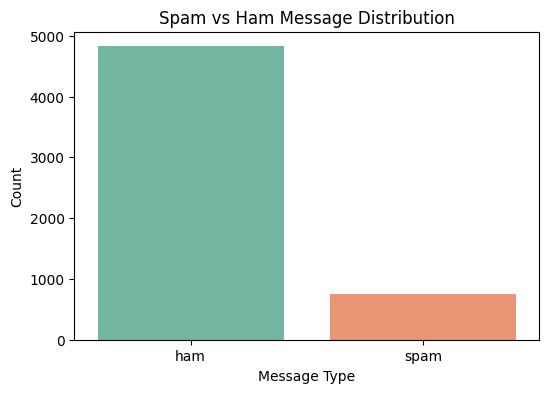


Model Accuracy: 0.97847533632287

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



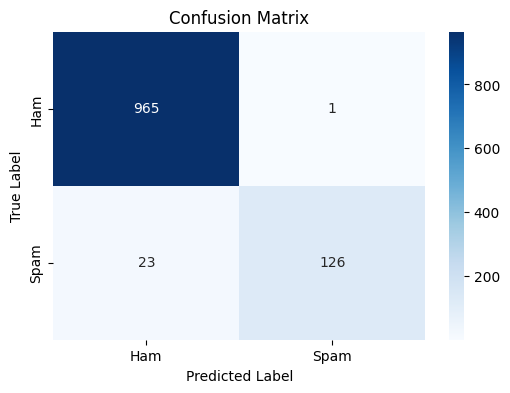

/tmp/ipython-input-193037082.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_words, palette="viridis")


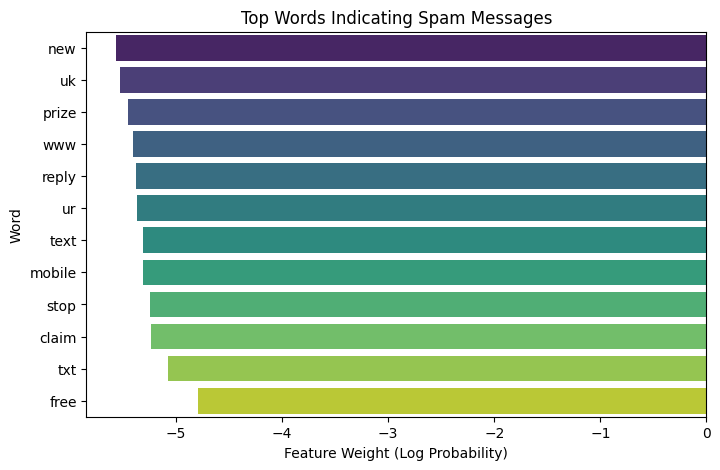


Model and vectorizer saved successfully!
Saved files: spam_classifier_model.pkl, tfidf_vectorizer.pkl


In [1]:
# -------------------------------------------------------
# SPAM MAIL CLASSIFICATION USING TF-IDF + NAIVE BAYES
# NLP | Text Preprocessing | Classification | Visualization
# -------------------------------------------------------

# Import required libraries
import pandas as pd
import requests
import io
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# -------------------------------------------------------
# Load Dataset from Online Source
# -------------------------------------------------------
DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

print("Downloading dataset...")
response = requests.get(DATA_URL)
response.raise_for_status()

# Convert into DataFrame
df = pd.read_csv(io.StringIO(response.text), sep="\t", header=None, names=["label", "message"])
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

print("\nDataset loaded successfully.")
print("Total Samples:", len(df))
print(df.head())

# -------------------------------------------------------
# Exploratory Data Analysis (EDA)
# -------------------------------------------------------

# Class distribution visualization
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", palette="Set2")
plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

# -------------------------------------------------------
# Train-Test Split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label_num"], test_size=0.2, random_state=42, stratify=df["label_num"]
)

# -------------------------------------------------------
# TF-IDF Vectorization
# -------------------------------------------------------
vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# -------------------------------------------------------
# Model Training (Multinomial Naive Bayes)
# -------------------------------------------------------
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# -------------------------------------------------------
# Prediction & Evaluation
# -------------------------------------------------------
y_pred = model.predict(X_test_tfidf)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------------------------------
# Confusion Matrix Heatmap
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham","Spam"], yticklabels=["Ham","Spam"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# -------------------------------------------------------
# Top Spam Indicators - Feature Importance
# -------------------------------------------------------
feature_names = vectorizer.get_feature_names_out()

# Selecting top influential words for spam class
top_indices = np.argsort(model.feature_log_prob_[1])[-12:]
top_words = feature_names[top_indices]
top_values = model.feature_log_prob_[1][top_indices]

plt.figure(figsize=(8,5))
sns.barplot(x=top_values, y=top_words, palette="viridis")
plt.title("Top Words Indicating Spam Messages")
plt.xlabel("Feature Weight (Log Probability)")
plt.ylabel("Word")
plt.show()


# -------------------------------------------------------
# Save Model and Vectorizer for Deployment
# -------------------------------------------------------
import joblib

joblib.dump(model, "spam_classifier_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("\nModel and vectorizer saved successfully!")
print("Saved files: spam_classifier_model.pkl, tfidf_vectorizer.pkl")
